<a href="https://colab.research.google.com/github/chaudhary-hadi27/Hands-On-ML-with-SK-Learn-Keras-and-TF/blob/main/part1/chapter_02/lets_dirty_your_hand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Perform data cleaning and exploratory data analysis on the "House_Price_Prediction_Dataset.csv" dataset, handling missing and duplicate values, identifying and dropping unnecessary columns, and providing insights from EDA, to prepare a cleaned dataset.

## Load Dataset

### Subtask:
Load the 'House_Price_Prediction_Dataset.csv' file into a pandas DataFrame.


**Reasoning**:
To load the dataset, I need to import the pandas library and then use its `read_csv` function. Displaying the head of the DataFrame will confirm successful loading.



In [17]:
import pandas as pd
df = pd.read_csv('House_Price_Prediction_Dataset.csv')
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## Initial Data Inspection

### Subtask:
Display the first few rows, data types, and a summary of the dataset to understand its structure and identify potential issues.


**Reasoning**:
To understand the dataset's structure, identify data types, and get a statistical summary, I will display the first few rows, information about the columns (including data types and non-null counts), and descriptive statistics for numerical columns.



In [18]:
print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
df.describe()

First 5 rows of the DataFrame:
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


## Handle Missing Values

### Subtask:
Identify and handle any missing values in the dataset. This might involve imputation, dropping rows/columns, or other appropriate strategies based on the nature of the missing data.


**Reasoning**:
To identify any missing values, I will use `.isnull().sum()` to get a count of missing values per column and then `.isnull().sum().sum()` to get the total number of missing values in the entire DataFrame.



In [19]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing values in the dataset:")
print(df.isnull().sum().sum())

Missing values per column:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Total missing values in the dataset:
0


## Handle Duplicate Values

### Subtask:
Check for and remove any duplicate rows in the dataset to ensure data integrity.


**Reasoning**:
To identify and handle duplicate rows, I will first calculate the number of duplicate rows using `duplicated().sum()` and then remove them using `drop_duplicates(inplace=True)`, printing the shape before and after to confirm the action.



In [20]:
print("Number of duplicate rows before removal:", df.duplicated().sum())

if df.duplicated().sum() > 0:
    print("Shape of DataFrame before dropping duplicates:", df.shape)
    df.drop_duplicates(inplace=True)
    print("Shape of DataFrame after dropping duplicates:", df.shape)
else:
    print("No duplicate rows found.")

Number of duplicate rows before removal: 0
No duplicate rows found.


## Exploratory Data Analysis (EDA)

### Subtask:
Perform exploratory data analysis to gain useful insights. This will include generating descriptive statistics, visualizing distributions of key numerical features, and examining relationships between features relevant for house price prediction.


**Reasoning**:
To understand the distribution and unique values of categorical features, I will display descriptive statistics for all object-type columns in the DataFrame `df`.



In [21]:
print("Descriptive statistics for categorical columns:")
df.describe(include='object')

Descriptive statistics for categorical columns:


,Location,Condition,Garage
count,2000,2000,2000
unique,4,4,2
top,Downtown,Fair,No
freq,558,521,1038


**Reasoning**:
To visualize the distributions of numerical features, I will generate histograms for the specified numerical columns using `matplotlib.pyplot`. This will help in understanding the spread and central tendency of these features.



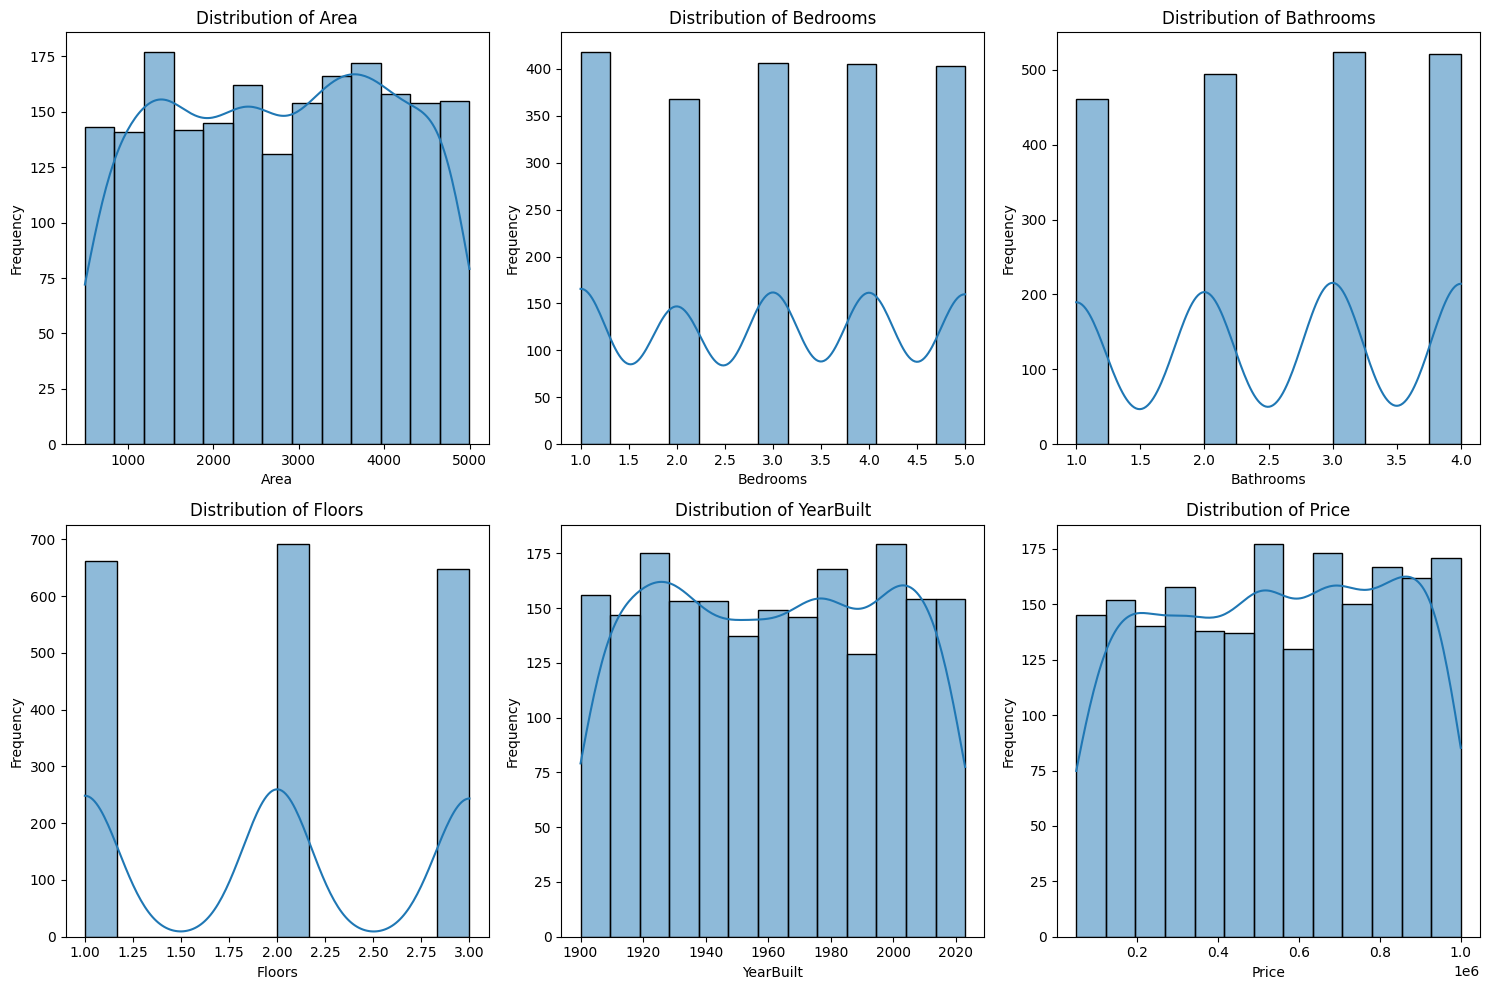

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns for histograms
numerical_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']

# Plotting histograms for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the frequency of each category for the categorical features, I will generate count plots using `seaborn` for 'Location', 'Condition', and 'Garage'. This will help understand the distribution of values within these columns.



/tmp/ipython-input-23-3800250088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipython-input-23-3800250088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')
/tmp/ipython-input-23-3800250088.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='viridis')


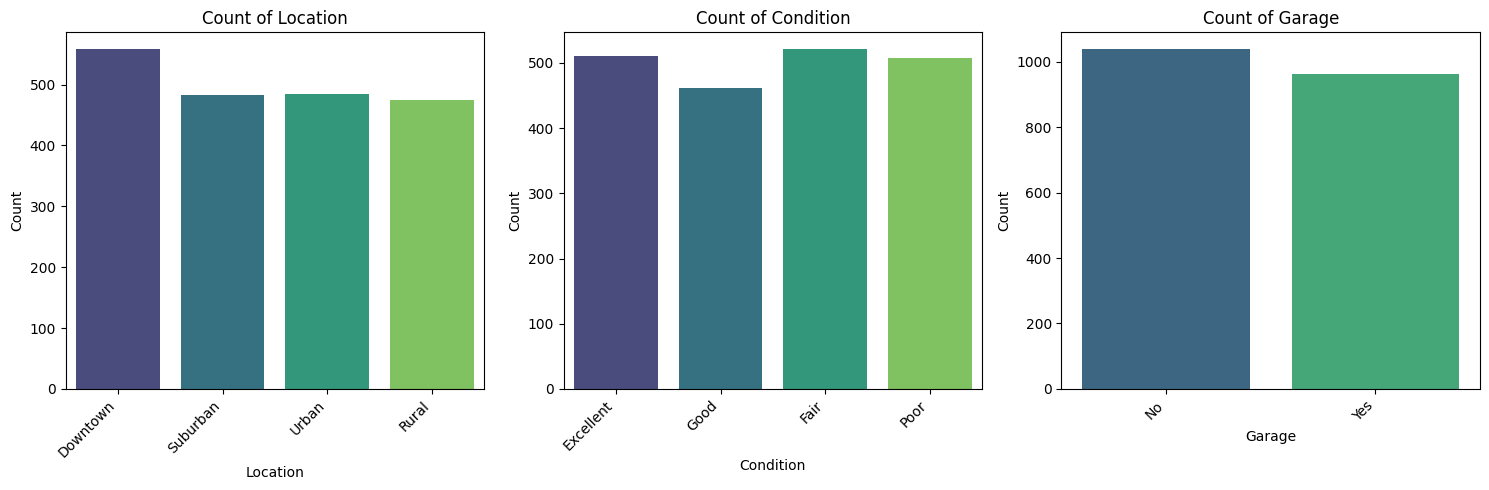

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical columns for count plots
categorical_cols = ['Location', 'Condition', 'Garage']

# Plotting count plots for categorical columns
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=df[col], palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a FutureWarning about using `palette` without `hue` in `sns.countplot`. To address this, I will modify the `countplot` call to explicitly assign the `x` variable to `hue` and set `legend=False`, as suggested by the warning, to ensure compatibility with future Seaborn versions.



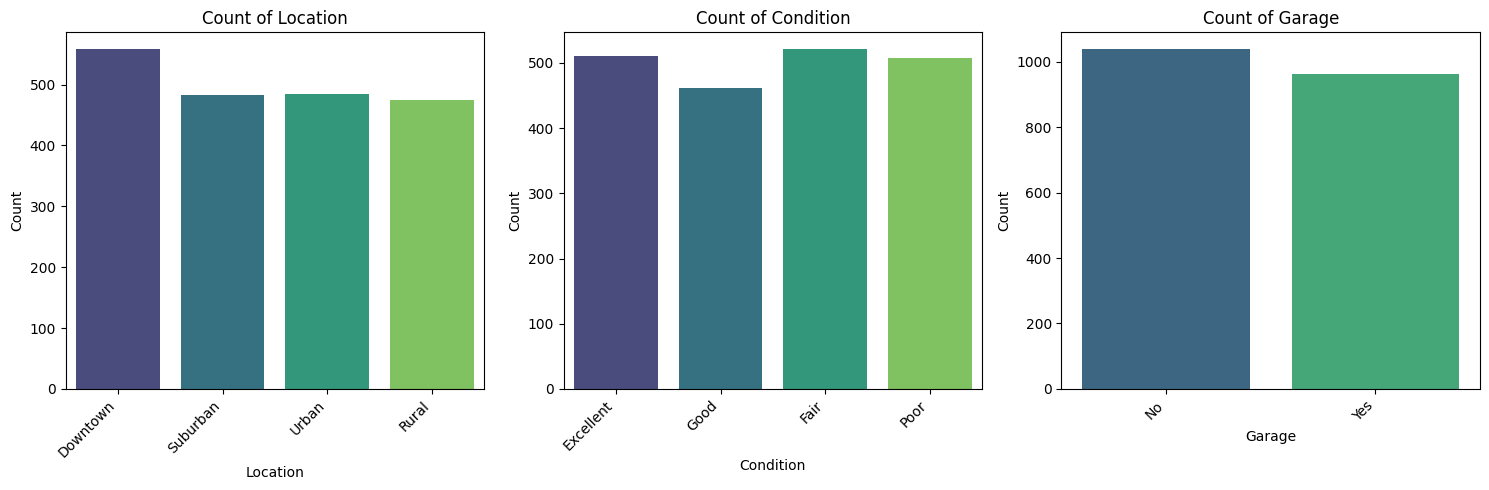

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical columns for count plots
categorical_cols = ['Location', 'Condition', 'Garage']

# Plotting count plots for categorical columns
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
To examine the relationship between numerical features and the 'Price' column, I will generate scatter plots for 'Area' vs 'Price' and 'YearBuilt' vs 'Price' using `seaborn.scatterplot`.



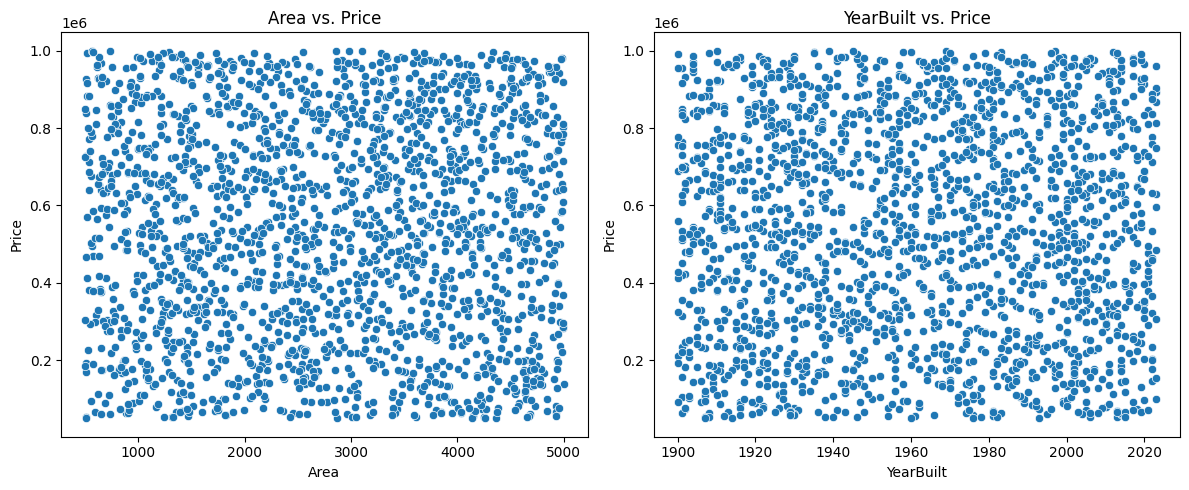

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns for scatter plots against Price
scatter_cols = ['Area', 'YearBuilt']

plt.figure(figsize=(12, 5))
for i, col in enumerate(scatter_cols):
    plt.subplot(1, 2, i + 1)
    sns.scatterplot(x=df[col], y=df['Price'])
    plt.title(f'{col} vs. Price')
    plt.xlabel(col)
    plt.ylabel('Price')
plt.tight_layout()
plt.show()

**Reasoning**:
To visualize the relationship between categorical features and the 'Price' column, I will generate box plots for 'Location', 'Condition', and 'Garage' against 'Price' using `seaborn.boxplot`.



/tmp/ipython-input-26-1581577997.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette='viridis')
/tmp/ipython-input-26-1581577997.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette='viridis')
/tmp/ipython-input-26-1581577997.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Price'], palette='viridis')


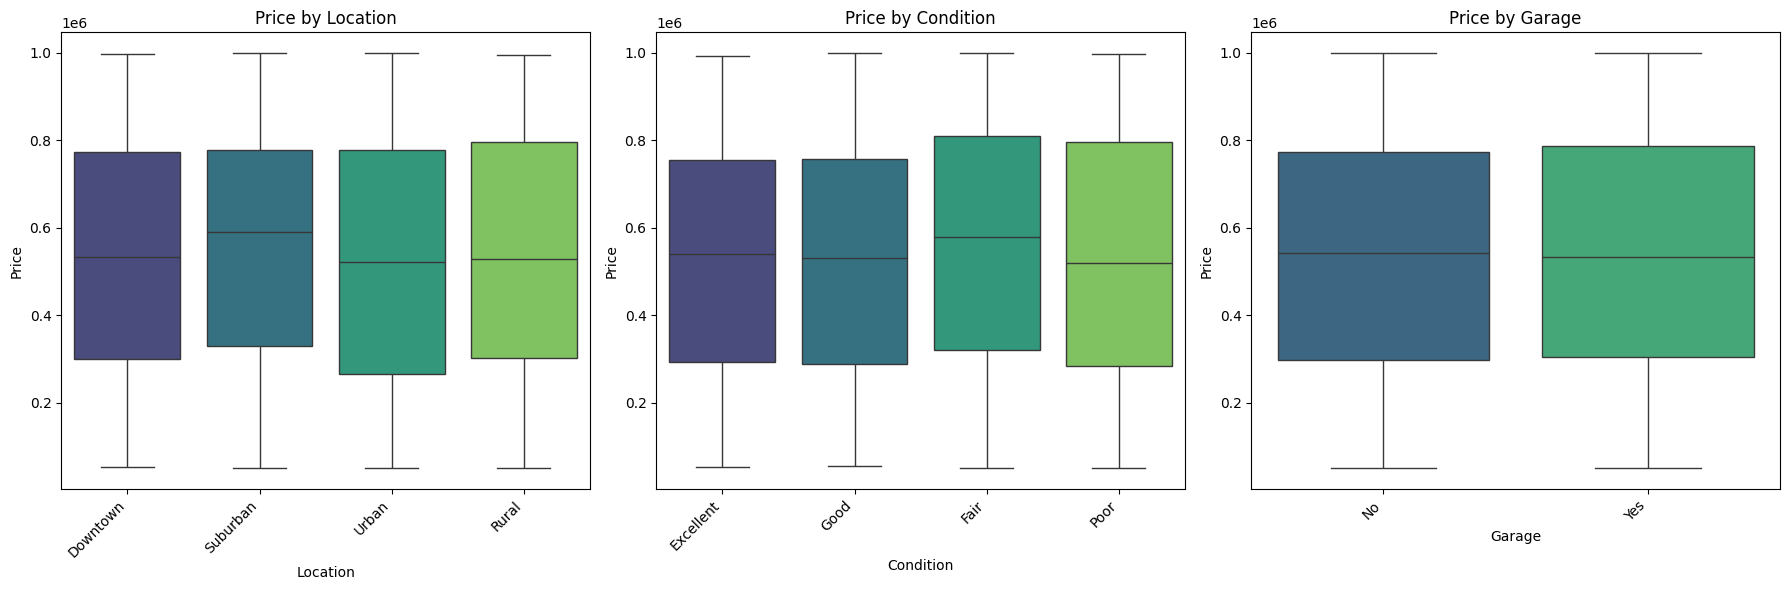

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical columns for box plots against Price
categorical_cols = ['Location', 'Condition', 'Garage']

plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=df[col], y=df['Price'], palette='viridis')
    plt.title(f'Price by {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a FutureWarning about using `palette` without `hue` in `sns.boxplot`. To address this, I will modify the `boxplot` call to explicitly assign the `x` variable to `hue` and set `legend=False`, as suggested by the warning, to ensure compatibility with future Seaborn versions.



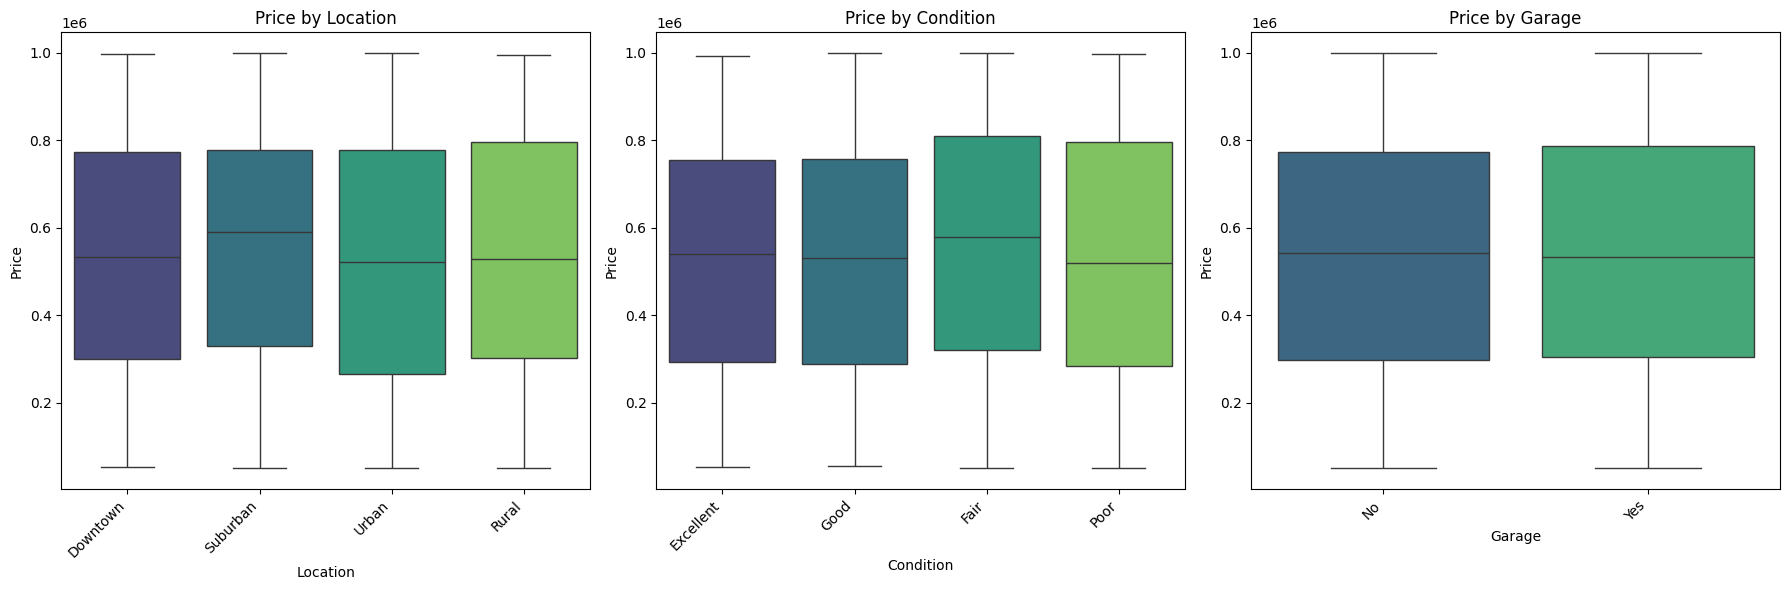

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Categorical columns for box plots against Price
categorical_cols = ['Location', 'Condition', 'Garage']

plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=df[col], y=df['Price'], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Price by {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Correlation Matrix

**Reasoning**:
To understand the linear relationships between all numerical features, including the target variable 'Price', I will compute the correlation matrix and visualize it using a heatmap. This helps identify strongly correlated features, which can be useful for feature selection and model building.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation matrix
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute the correlation matrix
correlation_matrix = df[numerical_cols].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
Area,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542
Bedrooms,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471
Bathrooms,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737
Floors,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890
YearBuilt,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845
Price,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000


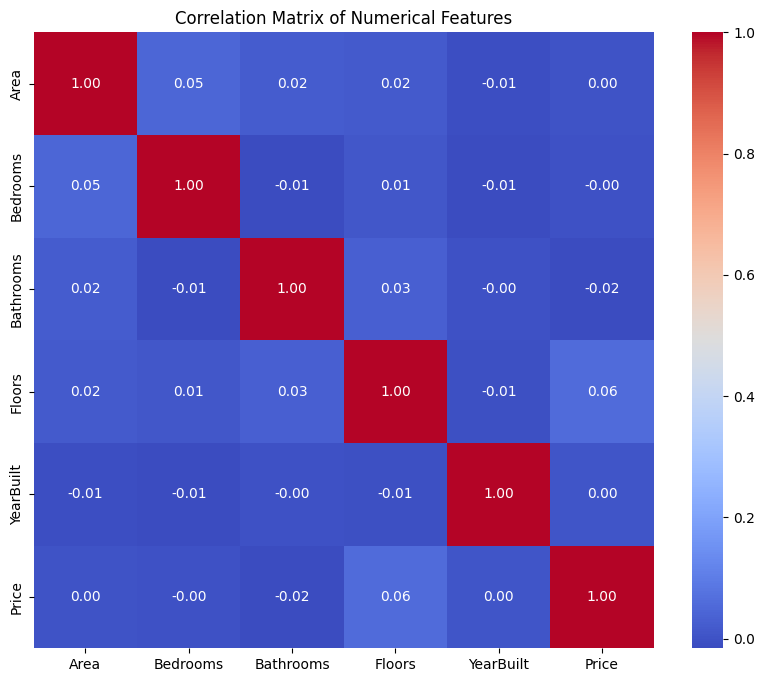

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Identify and Drop Unnecessary Columns

### Subtask:
Based on the EDA and the objective of house price prediction, identify and remove columns that are deemed irrelevant, redundant, or would not contribute positively to the prediction model.


**Reasoning**:
Based on the initial inspection, the 'Id' column appears to be a unique identifier and does not contribute to house price prediction, therefore, I will remove it from the DataFrame.



In [28]:
print("Columns before dropping 'Id':", df.columns.tolist())
df.drop('Id', axis=1, inplace=True)
print("Columns after dropping 'Id':", df.columns.tolist())

print("\nFirst 5 rows of the DataFrame after dropping 'Id' column:")
print(df.head())

print("\nDataFrame Info after dropping 'Id' column:")
df.info()

Columns before dropping 'Id': ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']
Columns after dropping 'Id': ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']

First 5 rows of the DataFrame after dropping 'Id' column:
   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition Garage  \
0  1360         5          4       3       1970  Downtown  Excellent     No   
1  4272         5          4       3       1958  Downtown  Excellent     No   
2  3592         2          2       3       1938  Downtown       Good     No   
3   966         4          2       2       1902  Suburban       Fair    Yes   
4  4926         1          4       2       1975  Downtown       Fair    Yes   

    Price  
0  149919  
1  424998  
2  266746  
3  244020  
4  636056  

DataFrame Info after dropping 'Id' column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data colu